In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Variables

In [2]:
start = time.time()

#Value of gravitational acceleration
g = 1

#Length and mass of the top rod
l1 = 1
m1 = 1
#Length and mass of the second rod
l2 = l1
m2 = 1

# Class for Double Pendulum

In [3]:
class Double_Pendulum : 
    def __init__(self, t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0) : 
        self.t1 = t1
        self.g = g
        self.l1 = l1
        self.l2 = l2
        self.m1 = m1
        self.m2 = m2
        self.theta1_0 = theta1_0
        self.v1_0 = v1_0
        self.theta2_0 = theta2_0
        self.v2_0 = v2_0
    
    def RK4(self, v2_0, theta2_0, h):
    
        #Initialise the arrays to be used
        # t is an array containing each of the timepoints that we will step forward to
        t = np.arange(0,t1+h,h)
        # n is the number of timesteps in t
        n = np.shape(t)[0]
        # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
        theta1 = np.zeros(n)
        theta2 = np.zeros(n)
        #same for velocities
        v1 = np.zeros(n)
        v2 = np.zeros(n)
    
        M = m1+m2
    
        #Set the initial value of x and v
        theta1[0] = theta1_0
        v1[0] = v1_0
        theta2[0] = theta2_0
        v2[0] = v2_0
    
        #define F(theta) for coupled equation 1
        def F1(theta1, theta2, v1, v2):
        
            thetaDiff = theta1-theta2
            a = m1 + m2*(np.sin(thetaDiff))**2
        
            return (-np.sin(thetaDiff)*(m2*l1*v1**2*np.cos(thetaDiff)+m2*l2*v2**2)-g*(M*np.sin(theta1)-m2*np.sin(theta2)*np.cos(thetaDiff)))/(l1*a)
    
        #Define G(v) for coupled equation 1
        def G1(v1):
        
            return v1
    
        #define F(theta) for coupled equation 2
        def F2(theta1, theta2, v1, v2):
        
            thetaDiff = theta1-theta2
            a = m1 + m2*(np.sin(thetaDiff))**2
        
            return (np.sin(thetaDiff)*(M*l1*v1**2+m2*l2*v2**2*np.cos(thetaDiff))+g*(M*np.sin(theta1)*np.cos(thetaDiff)-M*np.sin(theta2)))/(l2*a)
    
        #Define G(v) for coupled equation 2
        def G2(v2):
        
            return v2
    
    
        #Loop over the time values and calculate the derivatives
        for i in range(1,n): 
            # Calculate the Runge - Kutta intermediate values for both formulas
            f1 = h * F1(theta1[i-1], theta2[i-1], v1[i-1], v2[i-1])
            f2 = h * F1(theta1[i-1]+f1/2, theta2[i-1]+f1/2, v1[i-1]+f1/2, v2[i-1]+f1/2)
            f3 = h * F1(theta1[i-1]+f2/2, theta2[i-1]+f2/2, v1[i-1]+f2/2, v2[i-1]+f2/2)
            f4 = h * F1(theta1[i-1]+f3, theta2[i-1]+f3, v1[i-1]+f3, v2[i-1]+f3)
        
            g1 = h * G1(v1[i-1])
            g2 = h * G1(v1[i-1]+g1/2)
            g3 = h * G1(v1[i-1]+g2/2)
            g4 = h * G1(v1[i-1]+g3)
        
            e1 = h * F2(theta1[i-1], theta2[i-1], v1[i-1], v2[i-1])
            e2 = h * F2(theta1[i-1]+e1/2, theta2[i-1]+e1/2, v1[i-1]+e1/2, v2[i-1]+e1/2)
            e3 = h * F2(theta1[i-1]+e2/2, theta2[i-1]+e2/2, v1[i-1]+e2/2, v2[i-1]+e2/2)
            e4 = h * F2(theta1[i-1]+e3, theta2[i-1]+e3, v1[i-1]+e3, v2[i-1]+e3)
        
            j1 = h * G2(v2[i-1])
            j2 = h * G2(v2[i-1]+j1/2)
            j3 = h * G2(v2[i-1]+j2/2)
            j4 = h * G2(v2[i-1]+j3)
        
            theta1[i] = theta1[i-1] + 1/6 * (g1 + 2*g2 + 2*g3 + g4)
            v1[i] = v1[i-1] + 1/6 * (f1 + 2*f2 + 2*f3 + f4)
        
            theta2[i] = theta2[i-1] + 1/6 * (j1 + 2*j2 + 2*j3 + j4)
            v2[i] = v2[i-1] + 1/6 * (e1 + 2*e2 + 2*e3 + e4)
        
        
        return(t,theta1,theta2,v1,v2)
    
    
    def PoincareFull(self, N,title="Default Title"):
        
        #Setting Size for the figure
        plt.figure(figsize=(15,10))
        
        #Setting an initial value for initial theta2 that will be used to create subsequent theta2 intitial values
        theta2_0_ = self.theta2_0
        M = m1+m2
        
        #An array to store values of potential energy using N to determine how many loops it does
        E = np.zeros(N+1)
        
        #Setting an initial energy for the first state of the system
        E[0] = m1*g*l1*np.cos(theta1_0)+m2*g*(l1*np.cos(theta1_0)+l2*np.cos(theta2_0_))
        for i in range(1, len(E)):
            print(i)
            
            #Setting a new initial theta2
            theta2_0 = i*theta2_0_
            
            #Setting a new potential energy using the new theta2
            
            E[i] = m1*g*l1*np.cos(theta1_0)+m2*g*(l1*np.cos(theta1_0)+l2*np.cos(theta2_0_))
            
            #Finding the difference between the new potential energy and the initial one to find the amount of kinetic energy to give the system
            EDiff = E[i]-E[0]
            
            #Setting an initial v2 using the kinetic energy
            v2_0 = (-m2*l1*l2*v1_0*np.cos(theta1_0-theta2_0)  +  np.sqrt( (m2*l1*l2*v1_0*np.cos(theta1_0-theta2_0))**2 - 2*m2*(l2**2) * (1/2*m1*((l1*v1_0)**2) + 1/2*m2*(l1**2)*(v1_0**2) - EDiff )  ) ) / (m2*(l2)**2)
            
            t,theta1,theta2,v1,v2 = self.RK4(v2_0, theta2_0, h)
            
            crossTheta2 = np.array([])
            crossV2 = np.array([])
        
            for i in range(len(theta1)-1):
                #Test to see if theta1 crosses 0
                if theta1[i] <= 0 and theta1[i+1] >= 0:
                    crossTheta2=np.append(crossTheta2,theta2[i])
                    crossV2=np.append(crossV2,v2[i])
                elif theta1[i] >= 0 and theta1[i+1] <= 0:
                    crossTheta2=np.append(crossTheta2,theta2[i])
                    crossV2=np.append(crossV2,v2[i])

                elif np.abs(theta1[i]) <= 0.1 and abs(theta1[i+1]) >= 2*np.pi-0.1:
                    crossTheta2=np.append(crossTheta2,theta2[i])
                    crossV2=np.append(crossV2,v2[i])
                elif np.abs(theta1[i]) >= 2*np.pi-0.1 and abs(theta1[i+1]) <= 0.1:
                    crossTheta2=np.append(crossTheta2,theta2[i])
                    crossV2=np.append(crossV2,v2[i])
                    
            plt.scatter(crossTheta2, crossV2, label="Initial Theta 2 = "+ str(np.round(theta2_0, 3)))
            
            
        plt.title(title, fontsize=20)
        plt.xlabel("Theta 2 (rad)", fontsize=20)
        plt.ylabel("Velocity 2 (rad/s)", fontsize=20)
        plt.legend(bbox_to_anchor=(1.3, 1), fontsize=15)
        plt.show()
        
        return 0
    
    def Poincare(self, title="Default Title"):
        crossTheta2 = np.array([])
        crossV2 = np.array([])
        t,theta1,theta2,v1,v2 = self.RK4(theta2_0, v2_0, h)
        
        for i in range(len(theta1)-1):
                #Test to see if theta1 crosses 0
            if theta1[i] <= 0 and theta1[i+1] >= 0:
                crossTheta2=np.append(crossTheta2,theta2[i])
                crossV2=np.append(crossV2,v2[i])
            elif theta1[i] >= 0 and theta1[i+1] <= 0:
                crossTheta2=np.append(crossTheta2,theta2[i])
                crossV2=np.append(crossV2,v2[i])

            elif np.abs(theta1[i]) <= 0.1 and abs(theta1[i+1]) >= 2*np.pi-0.1:
                crossTheta2=np.append(crossTheta2,theta2[i])
                crossV2=np.append(crossV2,v2[i])
            elif np.abs(theta1[i]) >= 2*np.pi-0.1 and abs(theta1[i+1]) <= 0.1:
                crossTheta2=np.append(crossTheta2,theta2[i])
                crossV2=np.append(crossV2,v2[i])

        plt.scatter(crossTheta2, crossV2, alpha=0.7)    
        plt.title(title, fontsize=20)
        plt.xlabel("Theta 2 (rad)", fontsize=20)
        plt.ylabel("Velocity 2 (rad/s)", fontsize=20)
        plt.savefig('poincare_one2oneL.png', dpi=300) 
        plt.show()
        
        return 0
    
print('hi')

hi


In [5]:
class Double_Pendulum : 
    def __init__(self, t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0) : 
        self.t1 = t1
        self.g = g
        self.l1 = l1
        self.l2 = l2
        self.m1 = m1
        self.m2 = m2
        self.theta1_0 = theta1_0
        self.v1_0 = v1_0
        self.theta2_0 = theta2_0
        self.v2_0 = v2_0
    
    def RK4(self, v2_0, theta2_0, h):
    
        #Initialise the arrays to be used
        # t is an array containing each of the timepoints that we will step forward to
        t = np.arange(0,t1+h,h)
        # n is the number of timesteps in t
        n = np.shape(t)[0]
        # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
        theta1 = np.zeros(n)
        theta2 = np.zeros(n)
        #same for velocities
        v1 = np.zeros(n)
        v2 = np.zeros(n)
    
        M = m1+m2
    
        #Set the initial value of x and v
        theta1[0] = theta1_0
        v1[0] = v1_0
        theta2[0] = theta2_0
        v2[0] = v2_0
    
        #define F(theta) for coupled equation 1
        def F1(theta1, theta2, v1, v2):
        
            thetaDiff = theta1-theta2
            a = m1 + m2*(np.sin(thetaDiff))**2
        
            return (-np.sin(thetaDiff)*(m2*l1*v1**2*np.cos(thetaDiff)+m2*l2*v2**2)-g*(M*np.sin(theta1)-m2*np.sin(theta2)*np.cos(thetaDiff)))/(l1*a)
    
        #Define G(v) for coupled equation 1
        def G1(v1):
        
            return v1
    
        #define F(theta) for coupled equation 2
        def F2(theta1, theta2, v1, v2):
        
            thetaDiff = theta1-theta2
            a = m1 + m2*(np.sin(thetaDiff))**2
        
            return (np.sin(thetaDiff)*(M*l1*v1**2+m2*l2*v2**2*np.cos(thetaDiff))+g*(M*np.sin(theta1)*np.cos(thetaDiff)-M*np.sin(theta2)))/(l2*a)
    
        #Define G(v) for coupled equation 2
        def G2(v2):
        
            return v2
    
    
        #Loop over the time values and calculate the derivatives
        for i in range(1,n): 
            # Calculate the Runge - Kutta intermediate values for both formulas
            f1 = h * F1(theta1[i-1], theta2[i-1], v1[i-1], v2[i-1])
            f2 = h * F1(theta1[i-1]+f1/2, theta2[i-1]+f1/2, v1[i-1]+f1/2, v2[i-1]+f1/2)
            f3 = h * F1(theta1[i-1]+f2/2, theta2[i-1]+f2/2, v1[i-1]+f2/2, v2[i-1]+f2/2)
            f4 = h * F1(theta1[i-1]+f3, theta2[i-1]+f3, v1[i-1]+f3, v2[i-1]+f3)
        
            g1 = h * G1(v1[i-1])
            g2 = h * G1(v1[i-1]+g1/2)
            g3 = h * G1(v1[i-1]+g2/2)
            g4 = h * G1(v1[i-1]+g3)
        
            e1 = h * F2(theta1[i-1], theta2[i-1], v1[i-1], v2[i-1])
            e2 = h * F2(theta1[i-1]+e1/2, theta2[i-1]+e1/2, v1[i-1]+e1/2, v2[i-1]+e1/2)
            e3 = h * F2(theta1[i-1]+e2/2, theta2[i-1]+e2/2, v1[i-1]+e2/2, v2[i-1]+e2/2)
            e4 = h * F2(theta1[i-1]+e3, theta2[i-1]+e3, v1[i-1]+e3, v2[i-1]+e3)
        
            j1 = h * G2(v2[i-1])
            j2 = h * G2(v2[i-1]+j1/2)
            j3 = h * G2(v2[i-1]+j2/2)
            j4 = h * G2(v2[i-1]+j3)
        
            theta1[i] = theta1[i-1] + 1/6 * (g1 + 2*g2 + 2*g3 + g4)
            v1[i] = v1[i-1] + 1/6 * (f1 + 2*f2 + 2*f3 + f4)
        
            theta2[i] = theta2[i-1] + 1/6 * (j1 + 2*j2 + 2*j3 + j4)
            v2[i] = v2[i-1] + 1/6 * (e1 + 2*e2 + 2*e3 + e4)
        
        
        return(t,theta1,theta2,v1,v2)
    
    
    def PoincareFull(self, N,title="Default Title"):
        
        #Setting Size for the figure
        plt.figure(figsize=(15,10))
        
        #Setting an initial value for initial theta2 that will be used to create subsequent theta2 intitial values
        theta2_0_ = self.theta2_0
        M = m1+m2
        
        #An array to store values of potential energy using N to determine how many loops it does
        E = np.zeros(N+1)
        
        #Setting an initial energy for the first state of the system
        E[0] = m1*g*l1*np.cos(theta1_0)+m2*g*(l1*np.cos(theta1_0)+l2*np.cos(theta2_0_))
        for i in range(1, len(E)):
            print(i)
            
            #Setting a new initial theta2
            theta2_0 = i*theta2_0_
            
            #Setting a new potential energy using the new theta2
            E[i] = m1*g*l1*np.cos(theta1_0)+m2*g*(l1*np.cos(theta1_0)+l2*np.cos(theta2_0_))
            
            #Finding the difference between the new potential energy and the initial one to find the amount of kinetic energy to give the system
            EDiff = E[i]-E[0]
            
            #Setting an initial v2 using the kinetic energy
            v2_0 = (-m2*l1*l2*v1_0*np.cos(theta1_0-theta2_0)  +  np.sqrt( (m2*l1*l2*v1_0*np.cos(theta1_0-theta2_0))**2 - 2*m2*(l2**2) * (1/2*m1*((l1*v1_0)**2) + 1/2*m2*(l1**2)*(v1_0**2) - EDiff )  ) ) / (m2*(l2)**2)
            
            t,theta1,theta2,v1,v2 = self.RK4(v2_0, theta2_0, h)
            
            crossTheta2 = np.array([])
            crossV2 = np.array([])
        
            for i in range(len(theta1)-1):
                #Test to see if theta1 crosses 0
                if theta1[i] <= 0 and theta1[i+1] >= 0:
                    crossTheta2=np.append(crossTheta2,theta2[i])
                    crossV2=np.append(crossV2,v2[i])
                elif theta1[i] >= 0 and theta1[i+1] <= 0:
                    crossTheta2=np.append(crossTheta2,theta2[i])
                    crossV2=np.append(crossV2,v2[i])

                elif np.abs(theta1[i]) <= 0.1 and abs(theta1[i+1]) >= 2*np.pi-0.1:
                    crossTheta2=np.append(crossTheta2,theta2[i])
                    crossV2=np.append(crossV2,v2[i])
                elif np.abs(theta1[i]) >= 2*np.pi-0.1 and abs(theta1[i+1]) <= 0.1:
                    crossTheta2=np.append(crossTheta2,theta2[i])
                    crossV2=np.append(crossV2,v2[i])
                    
            plt.scatter(crossTheta2, crossV2, label="In θ_2 = "+ str(np.round(theta2_0, 3)))
            
            
        plt.title(title, fontsize=20)
        plt.xlabel("θ_2 (rad)", fontsize=20)
        plt.ylabel("Velocity 2 (rad/s)", fontsize=20)
        plt.legend(bbox_to_anchor=(1.3, 1), fontsize=15)
        plt.grid(True)
        plt.show()
        
        return 0
    
    def Poincare(self, title="Default Title"):
        crossTheta2 = np.array([])
        crossV2 = np.array([])
        t, theta1, theta2, v1, v2 = self.RK4(self.theta2_0, self.v2_0, self.h)
        
        for i in range(len(theta1)-1):
            # Test to see if theta1 crosses 0
            if np.sign(theta1[i]) != np.sign(theta1[i+1]):
                crossTheta2 = np.append(crossTheta2, theta2[i])
                crossV2 = np.append(crossV2, v2[i])

        plt.scatter(crossTheta2, crossV2, alpha=0.7)    
        plt.title(title, fontsize=20)
        plt.xlabel("θ_2 (rad)", fontsize=20)
        plt.ylabel("Velocity 2 (rad/s)", fontsize=20)
        plt.savefig('poincare_one2oneL.png', dpi=300) 
        plt.grid(True)
        plt.show()
        
        return 0
    
print('hi')

hi


# Main Body

# Ratios of Different Variables for Small Angles

## Lengths 1 and 2

### Lissajou

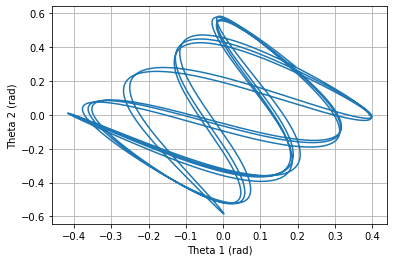

In [16]:
t1 = 25

theta1_0 = np.pi/8
theta2_0 = np.pi/16

v1_0 = 0
v2_0 = 0

m1 = 1
m2 = m1

l1 = 0.25
l2 = l1

h = 0.0005

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
#plt.title("1:1 Of Lengths")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.grid(True)
plt.savefig('lissajous_one_one_length.png',dpi=300)
plt.show()

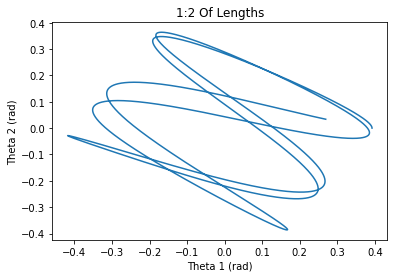

In [5]:
l2 = 2*l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("1:2 Of Lengths")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

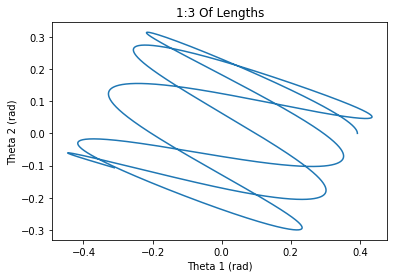

In [6]:
l2 = 3*l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("1:3 Of Lengths")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

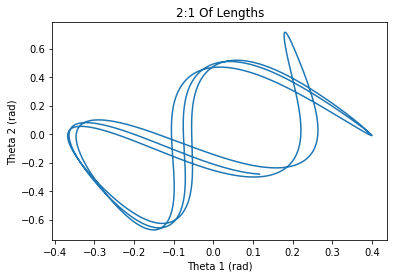

In [7]:
l2 = 0.5*l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("2:1 Of Lengths")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

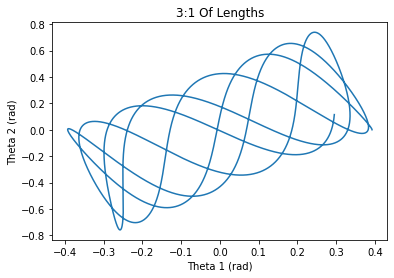

In [8]:
l2 = 1/3*l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("3:1 Of Lengths")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

### Poincare

1
2
3
4
5


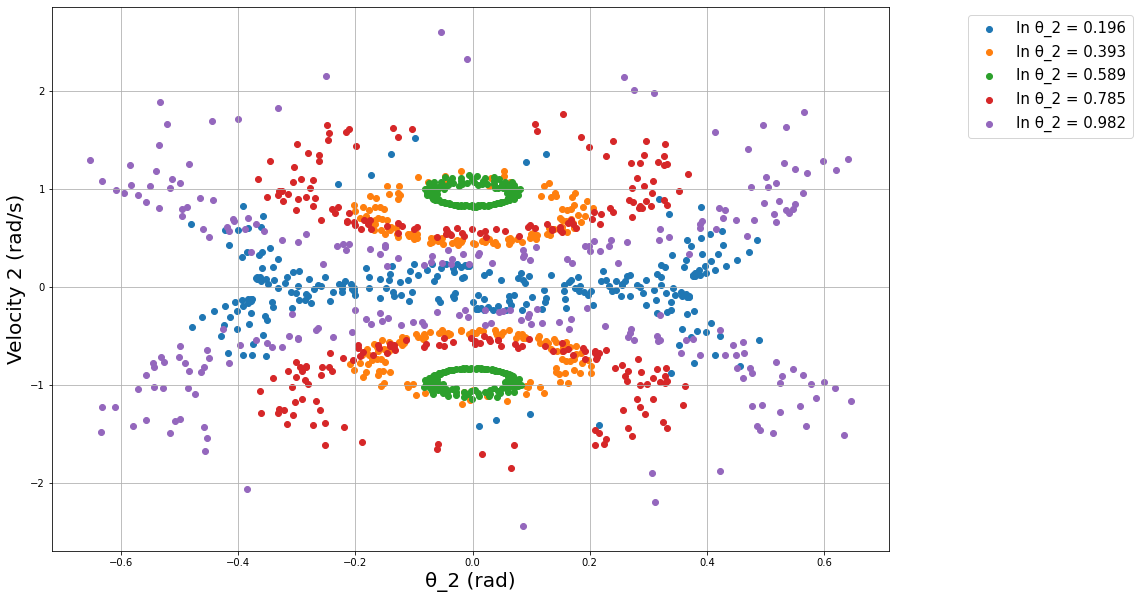

Execution time: 2184.642243385315 seconds


In [6]:
import time
start_time = time.time()

t1 = 500

theta1_0 = np.pi/8
theta2_0 = np.pi/16

v1_0 = 0
v2_0 = 0

m1 = 1
m2 = m1

l1 = 0.25
l2 = l1


h = 0.0001

l2 = l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.PoincareFull("1:1 Of Lengths")
double_p.PoincareFull(5, "")
#plt.savefig('poincare_one_one_length.png',dpi=300)

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

1
2
3
4
5


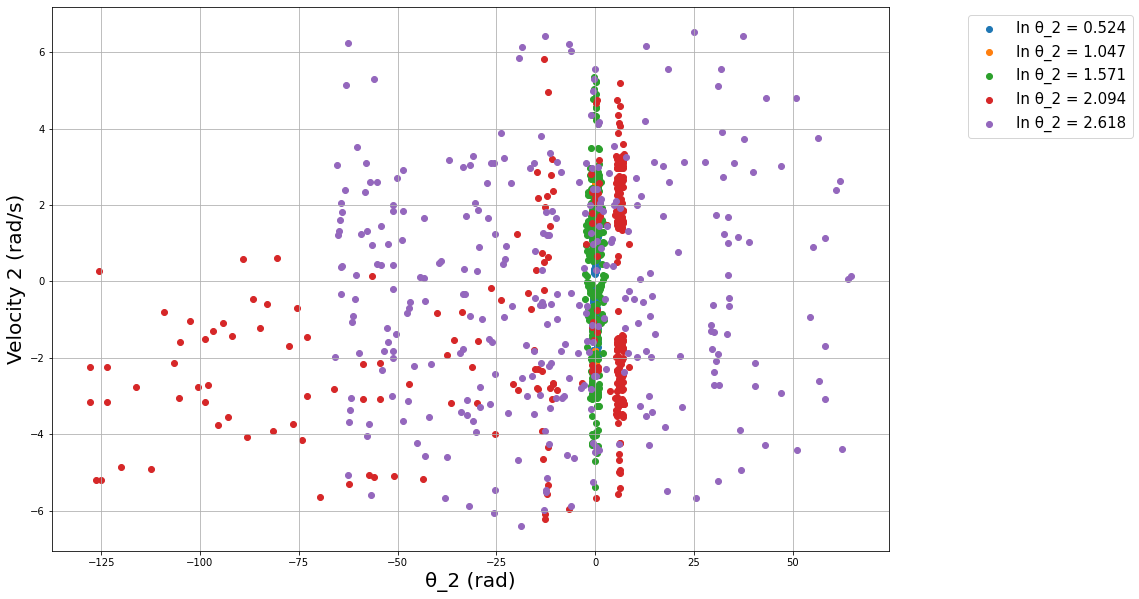

Execution time: 2167.7308065891266 seconds


In [7]:
import time
start_time = time.time()

t1 = 500

theta1_0 = np.pi/4
theta2_0 = np.pi/6

v1_0 = 0
v2_0 = 0

m1 = 1
m2 = m1

l1 = 0.25
l2 = l1


h = 0.0001

l2 = l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.PoincareFull("1:1 Of Lengths")
double_p.PoincareFull(5, "")
#plt.savefig('poincare_one_one_length.png',dpi=300)

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

In [4]:



t1 = 500

theta1_0 = np.pi/8
theta2_0 = np.pi/16

v1_0 = 0
v2_0 = 0

m1 = 1
m2 = m1

l1 = 0.25
l2 = l1


h = 0.0001

l2 = l1



# Create the double pendulum object
double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)

# Call the Poincare method to generate the plot
double_p.Poincare("1:1 Of Lengths")  # If this is the correct method to call
# If PoincareFull is the correct method, then keep the original call
# double_p.PoincareFull(5, "1:1 Of Lengths")


AttributeError: 'Double_Pendulum' object has no attribute 'h'

1
2
3
4
5


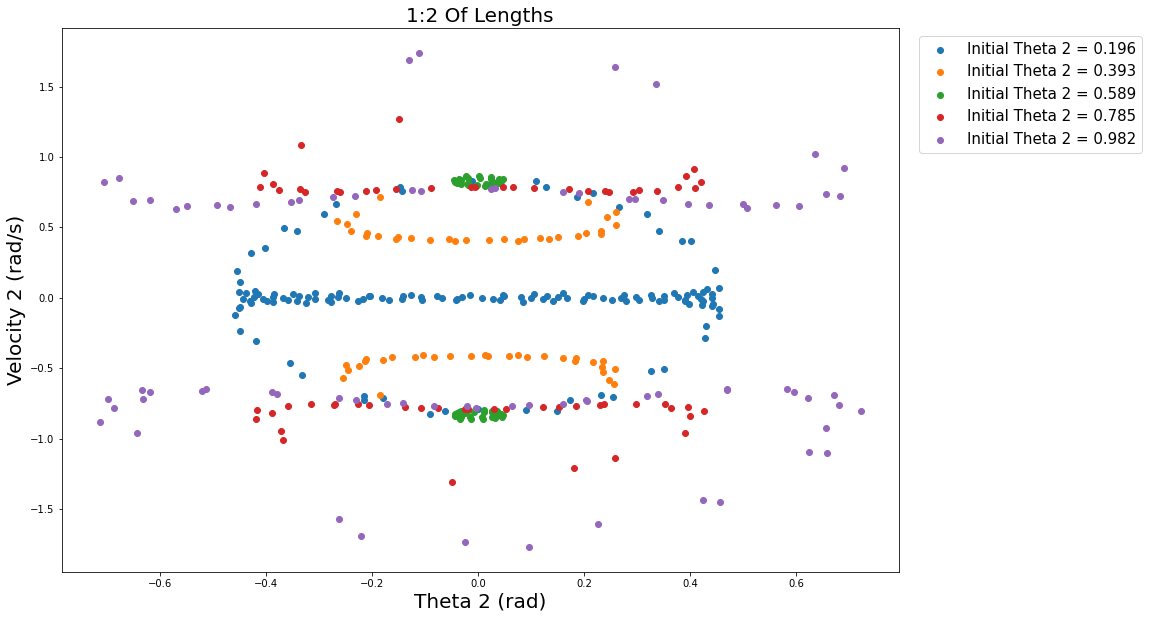

0

In [10]:
l2 = 2*l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"1:2 Of Lengths")
double_p.PoincareFull(5, "1:2 Of Lengths")

1
2
3
4
5


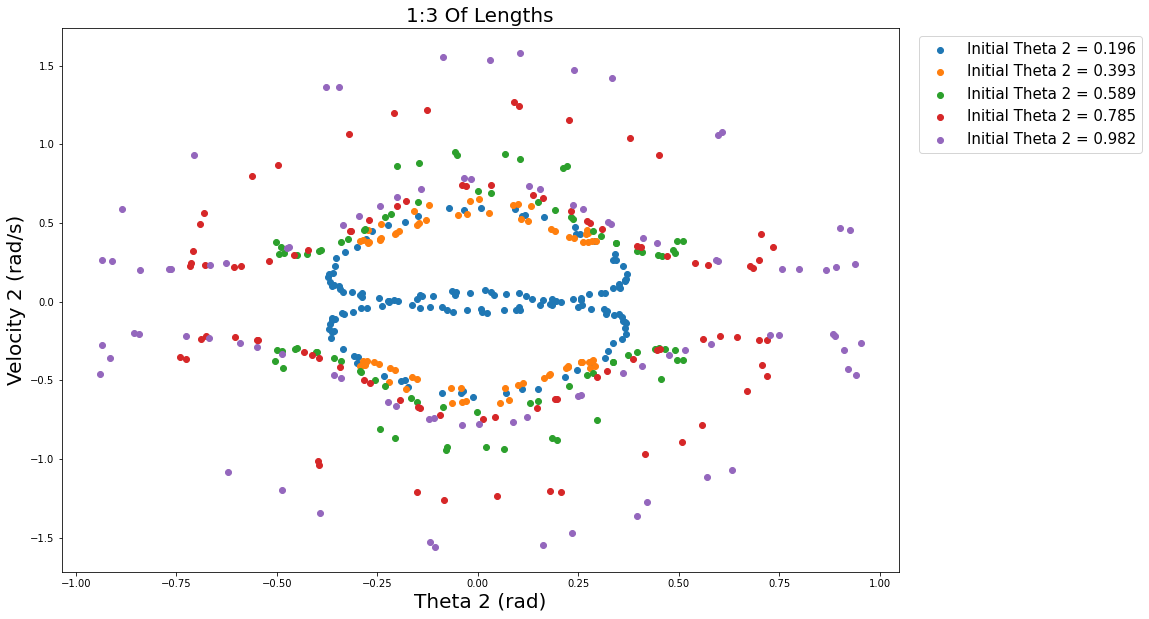

0

In [11]:
l2 = 3*l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"1:3 Of Lengths")
double_p.PoincareFull(5, "1:3 Of Lengths")

1
2
3
4
5


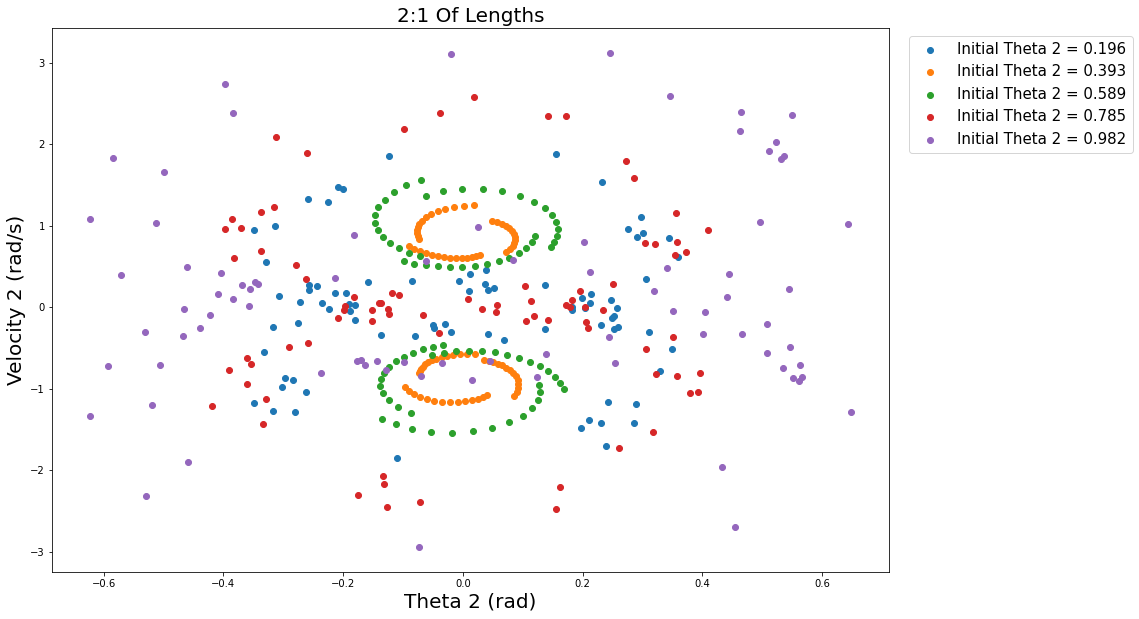

0

In [12]:
l2 = 0.5*l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"2:1 Of Lengths")
double_p.PoincareFull(5, "2:1 Of Lengths")

1
2
3
4
5


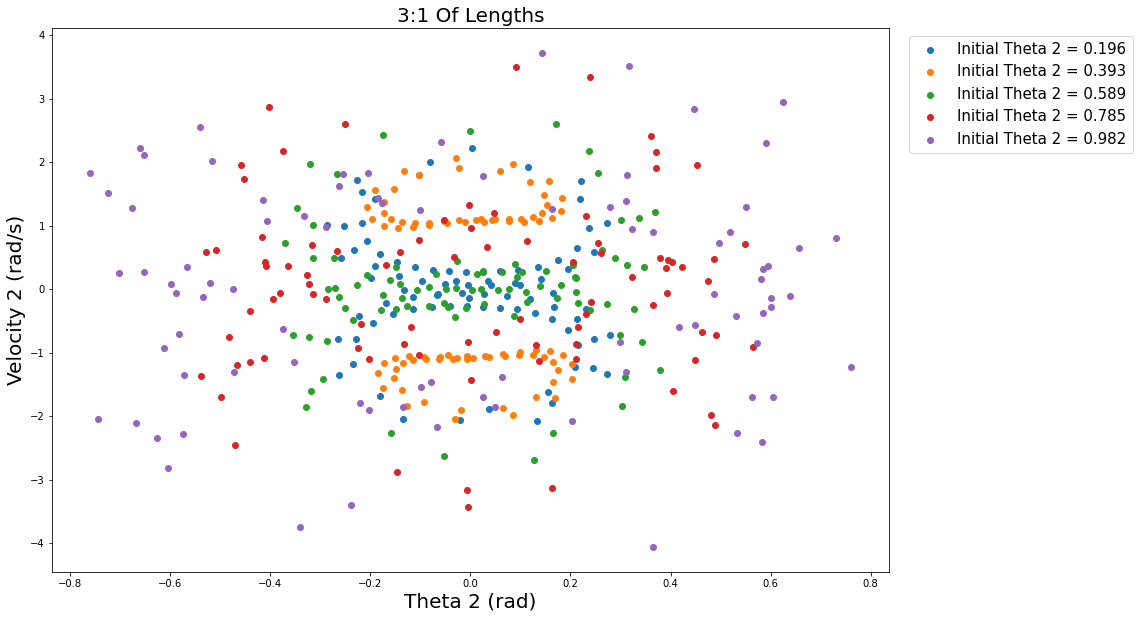

0

In [13]:
l2 = 1/3*l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"3:1 Of Lengths")
double_p.PoincareFull(5, "3:1 Of Lengths")

## Masses 1 and 2

### Lissajou

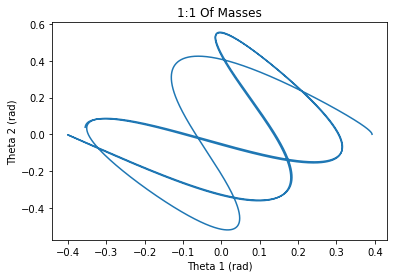

In [14]:
t1 = 10

v1_0 = 0
v2_0 = 0

l1 = 0.25
l2 = l1

m1 = 1
m2 = m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("1:1 Of Masses")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

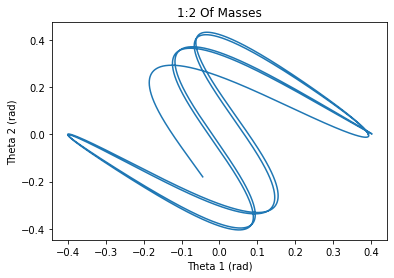

In [15]:
m1 = 1
m2 = 2*m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("1:2 Of Masses")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

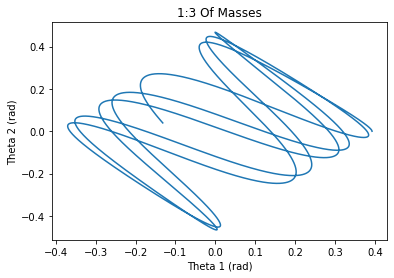

In [16]:
m1 = 1
m2 = 3*m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("1:3 Of Masses")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

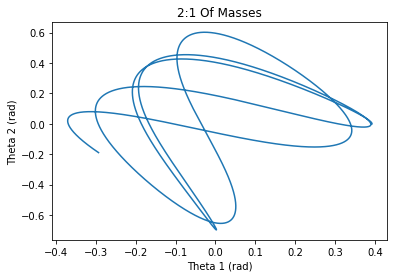

In [17]:
m1 = 1
m2 = 0.5*m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("2:1 Of Masses")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

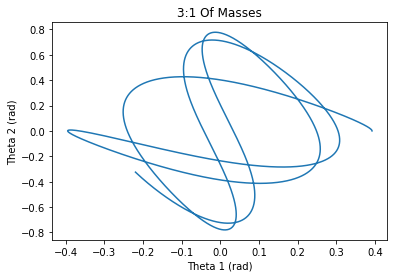

In [18]:
m1 = 1
m2 = 1/3*m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("3:1 Of Masses")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

### Poincare

1
2
3
4
5


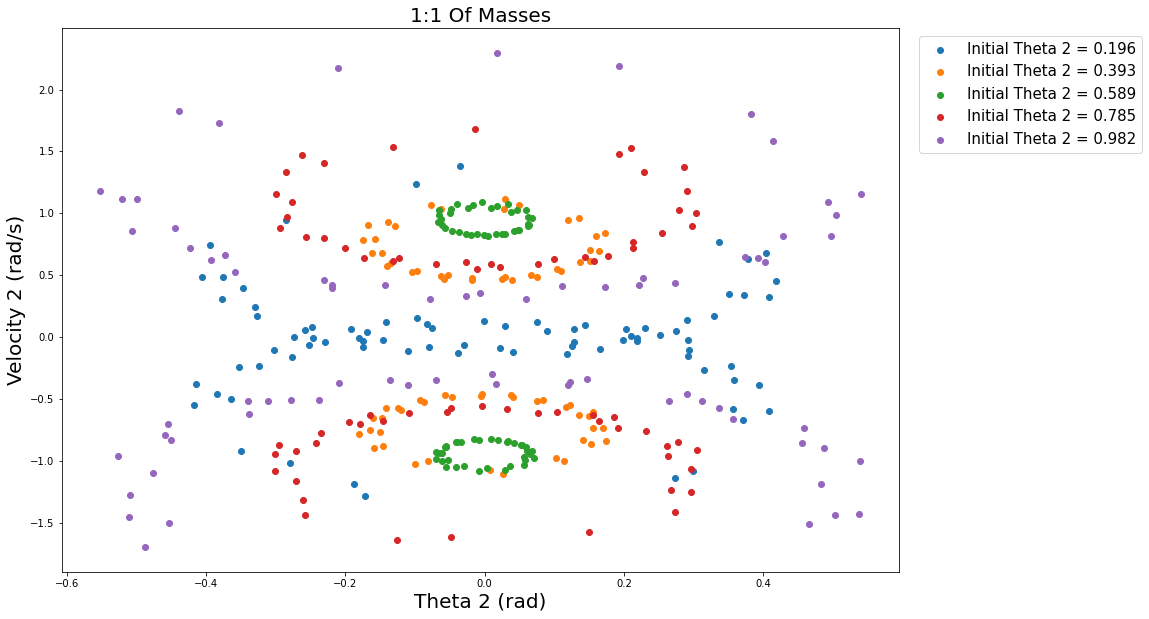

0

In [19]:
t1 = 150

m2 = m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"1:1 Of Masses")
double_p.PoincareFull(5, "1:1 Of Masses")

1
2
3
4
5


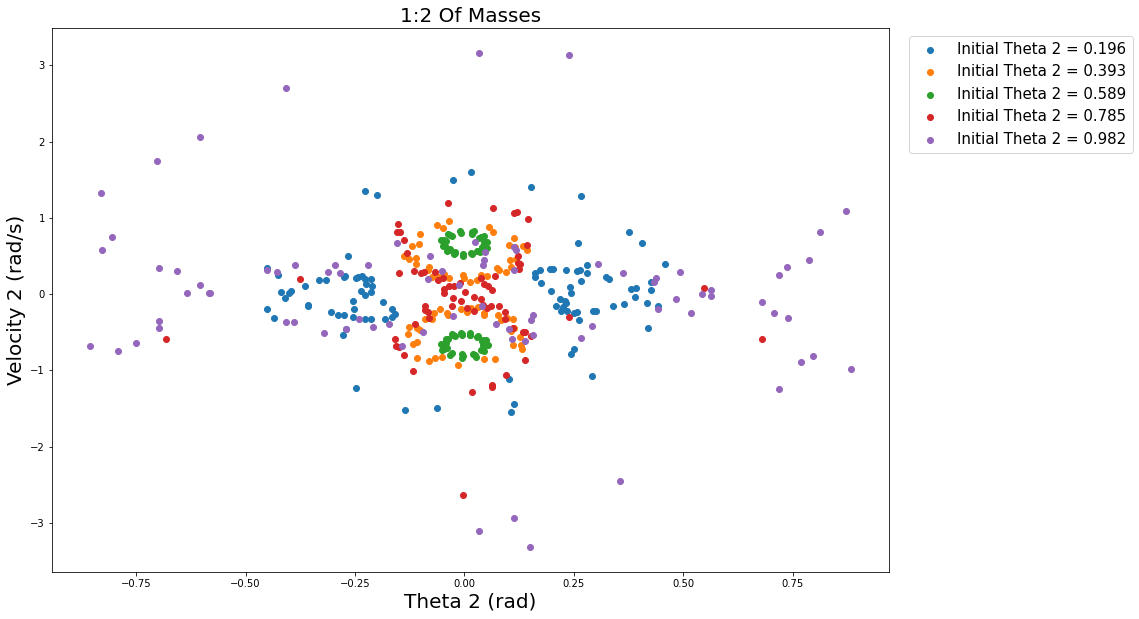

0

In [20]:
m2 = 2*m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"1:2 Of Masses")
double_p.PoincareFull(5, "1:2 Of Masses")

1
2
3
4
5


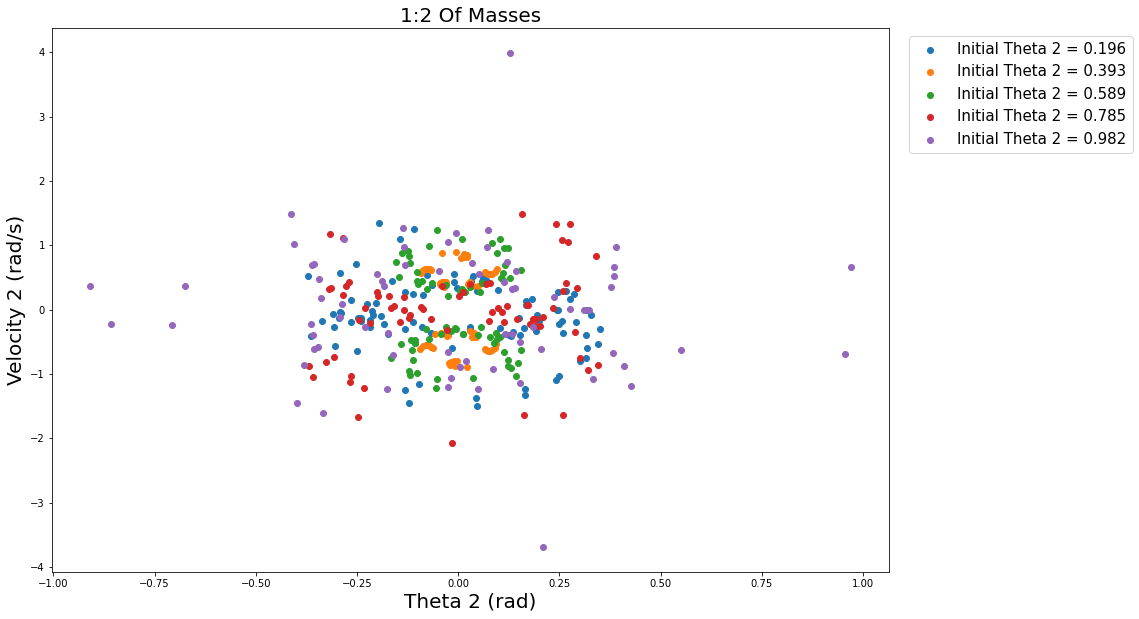

0

In [21]:
m2 = 3*m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"1:3 Of Masses")
double_p.PoincareFull(5, "1:2 Of Masses")

1
2
3
4
5


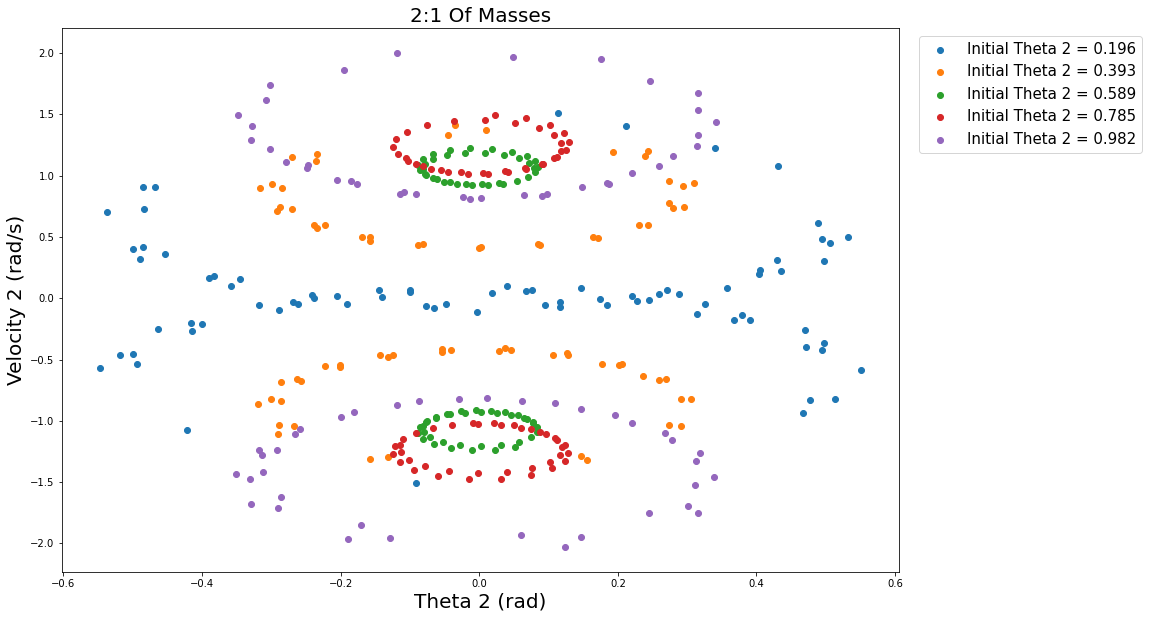

0

In [22]:
m2 = 0.5*m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"2:1 Of Masses")
double_p.PoincareFull(5, "2:1 Of Masses")

1
2
3
4
5


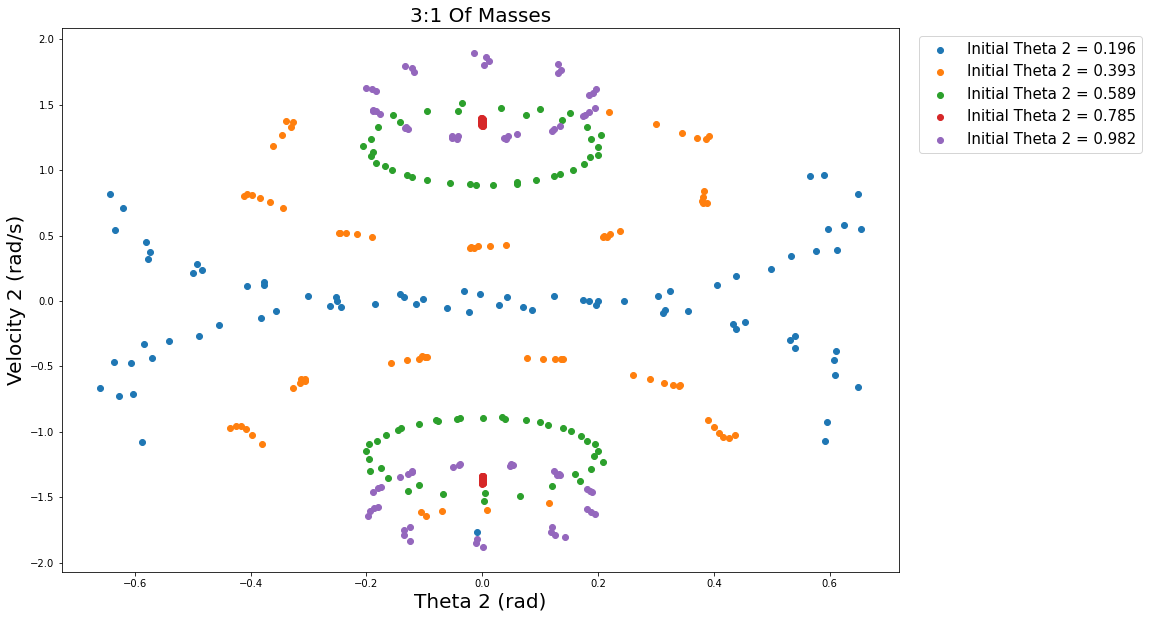

0

In [23]:
m2 = 1/3*m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"3:1 Of Masses")
double_p.PoincareFull(5, "3:1 Of Masses")

# Ratio Between Variables for a Large Angle

## Lengths 1 and 2

### Lissajou

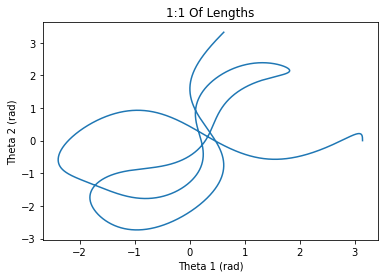

In [24]:
t1 = 10

v1_0 = 0
v2_0 = 0

theta1_0 = np.pi
theta2_0 = np.pi/5

l1 = 0.25
l2 = l1

m1 = 1
m2 = m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("1:1 Of Lengths")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

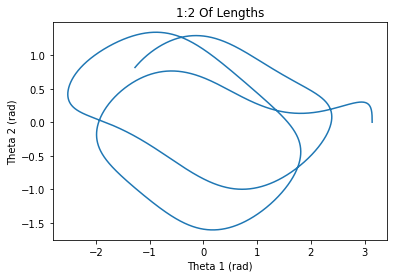

In [25]:
l2 = 2*l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("1:2 Of Lengths")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

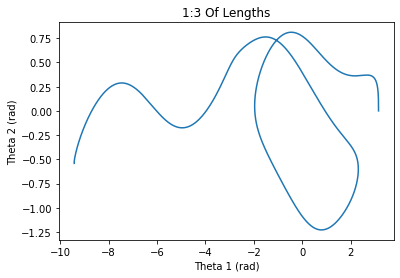

In [26]:
l2 = 3*l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("1:3 Of Lengths")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

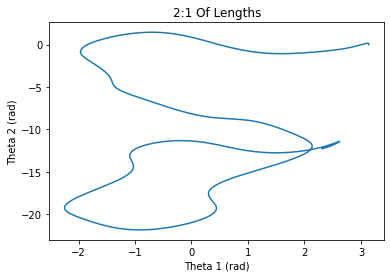

In [27]:
l2 = 0.5*l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("2:1 Of Lengths")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

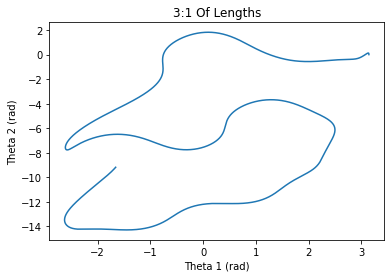

In [28]:
l2 = 1/3*l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("3:1 Of Lengths")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

### Poincare

1
2
3
4
5


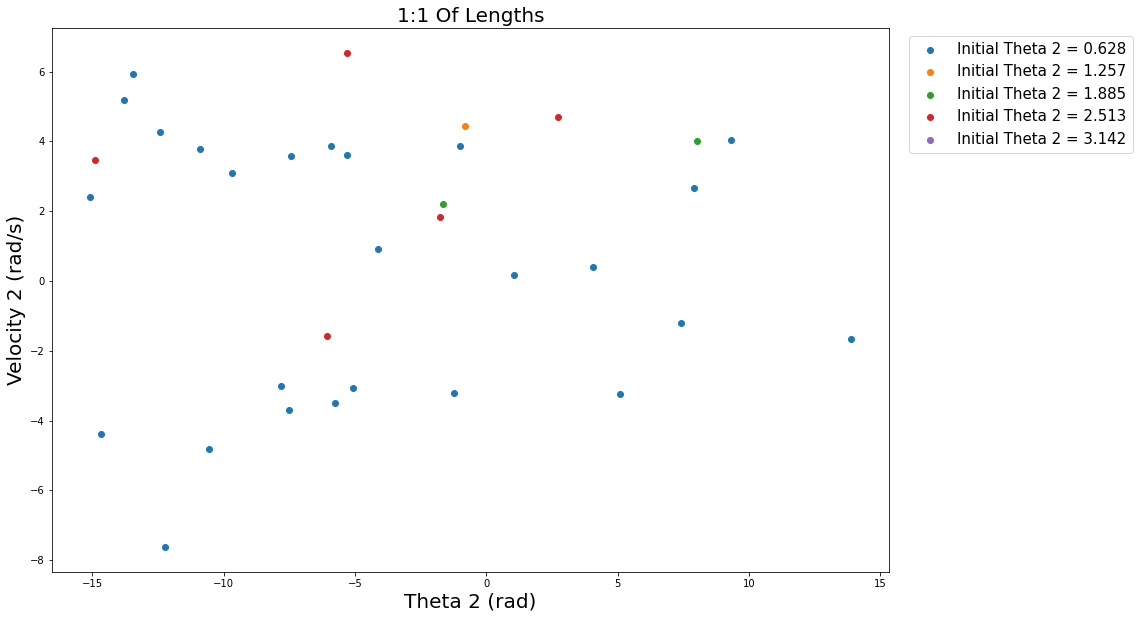

0

In [29]:
t1 = 50

l2 = l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"1:1 Of Lengths")
double_p.PoincareFull(5, "1:1 Of Lengths")

1
2
3
4
5


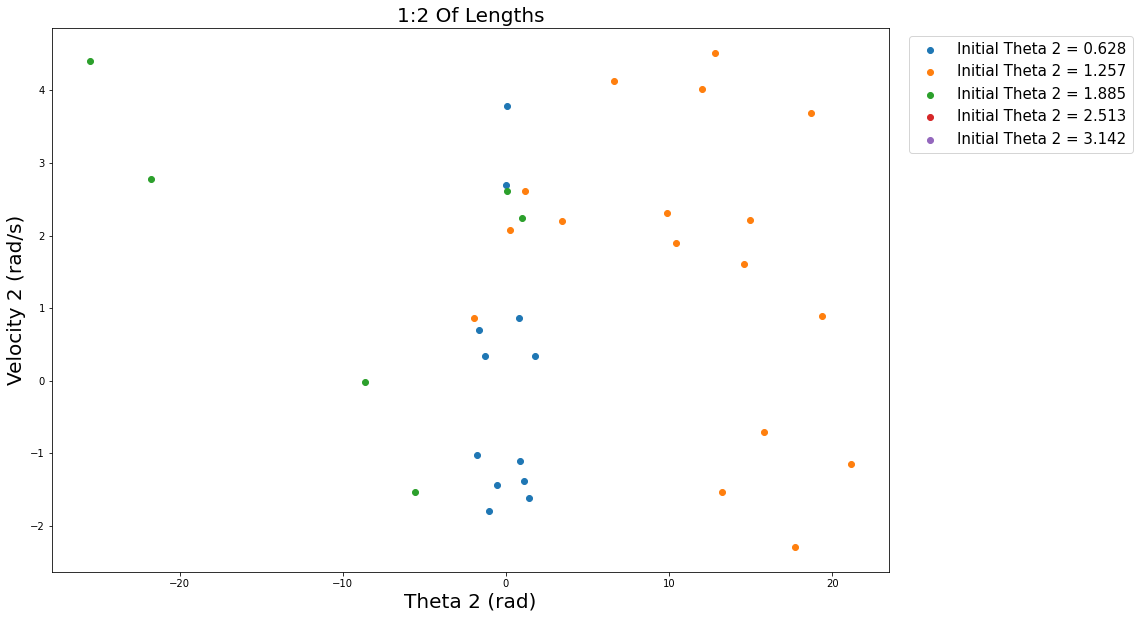

0

In [30]:
l2 = 2*l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"1:2 Of Lengths")
double_p.PoincareFull(5, "1:2 Of Lengths")

1
2
3
4
5


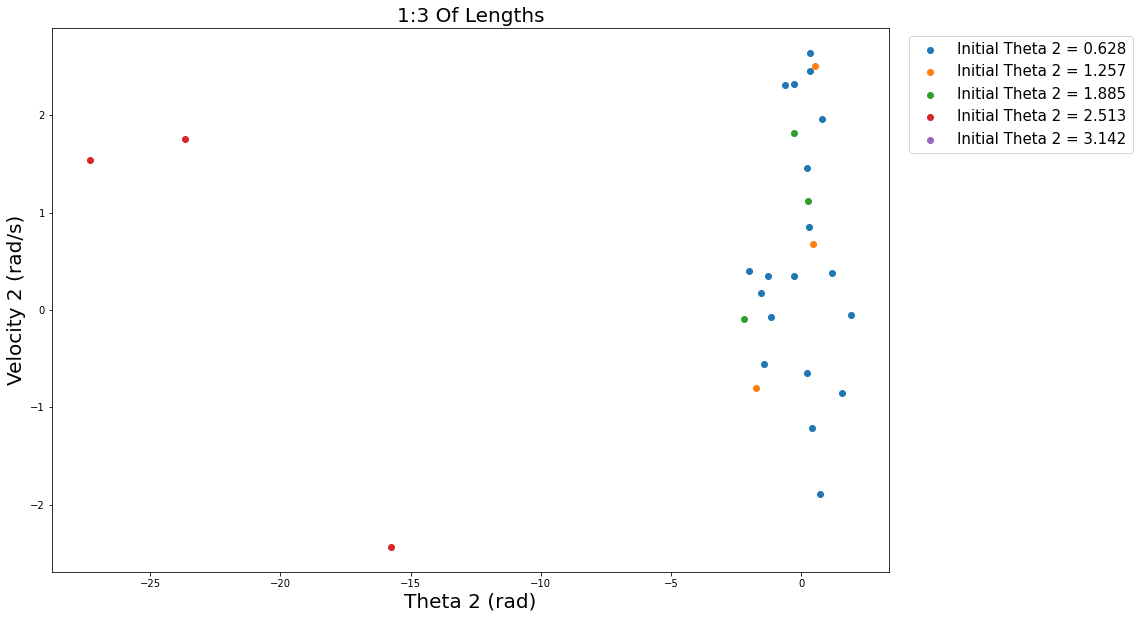

0

In [31]:
l2 = 3*l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"1:3 Of Lengths")
double_p.PoincareFull(5, "1:3 Of Lengths")

1
2
3
4
5


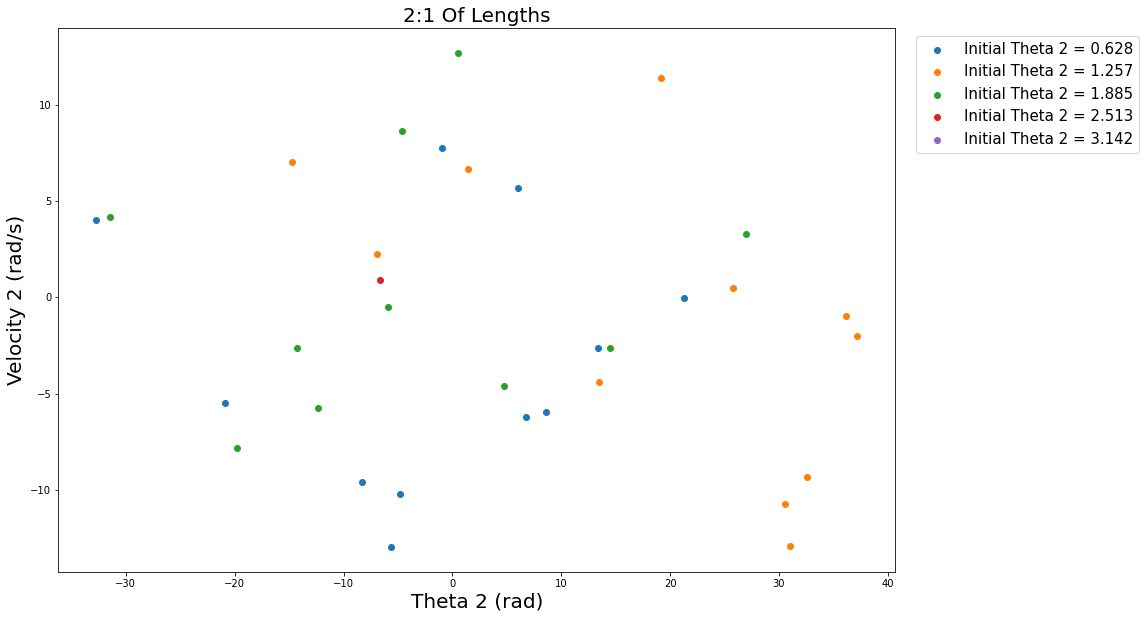

0

In [32]:
l2 = 0.5*l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"2:1 Of Lengths")
double_p.PoincareFull(5, "2:1 Of Lengths")

1
2
3
4
5


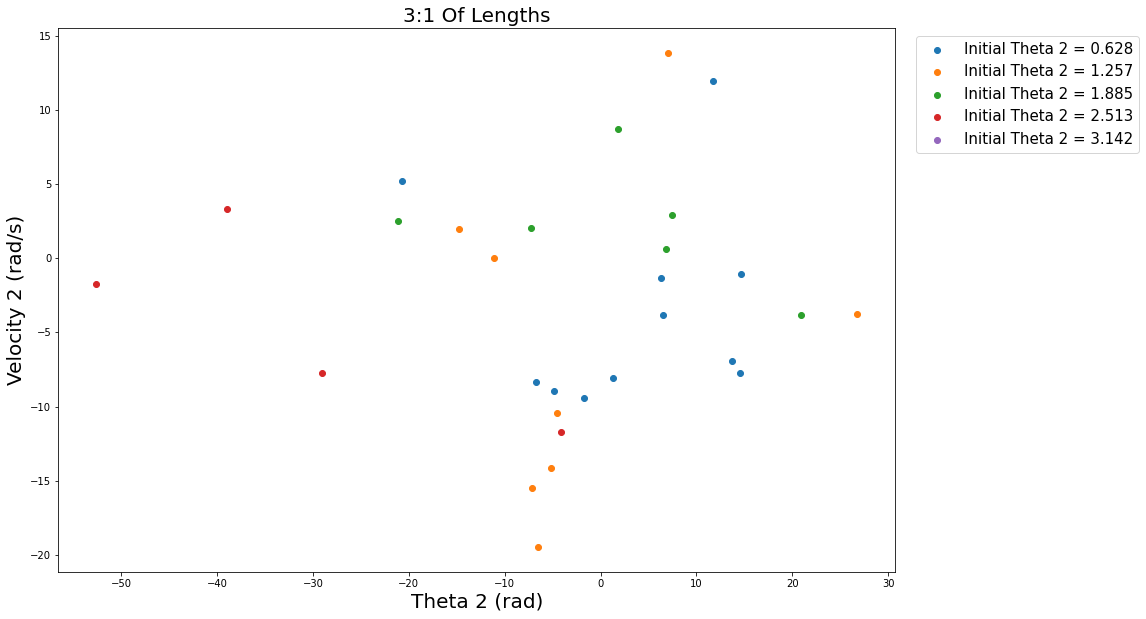

0

In [33]:
l2 = 1/3*l1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"3:1 Of Lengths")
double_p.PoincareFull(5, "3:1 Of Lengths")

## Masses 1 and 2

### Lissajou

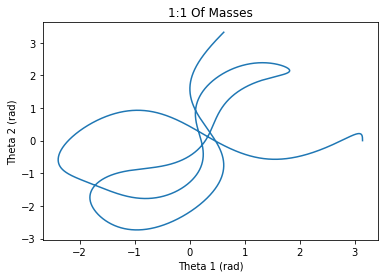

In [34]:
t1 = 10

v1_0 = 0
v2_0 = 0

l1 = 0.25
l2 = l1

m1 = 1
m2 = m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("1:1 Of Masses")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

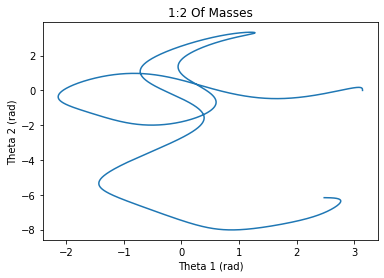

In [35]:
t1 = 10

v1_0 = 0
v2_0 = 0

l1 = 0.25
l2 = l1

m1 = 1
m2 = 2*m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("1:2 Of Masses")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

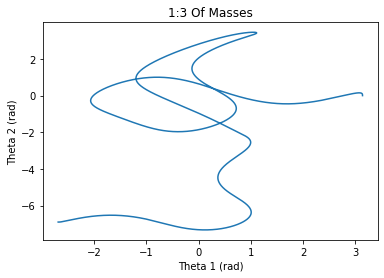

In [36]:
t1 = 10

v1_0 = 0
v2_0 = 0

l1 = 0.25
l2 = l1

m1 = 1
m2 = 3*m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("1:3 Of Masses")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

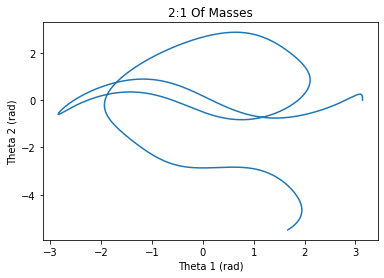

In [37]:
t1 = 10

v1_0 = 0
v2_0 = 0

l1 = 0.25
l2 = l1

m1 = 1
m2 = 0.5*m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("2:1 Of Masses")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

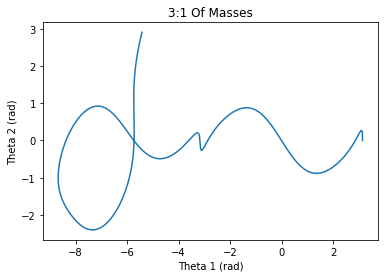

In [38]:
t1 = 10

v1_0 = 0
v2_0 = 0

l1 = 0.25
l2 = l1

m1 = 1
m2 = 1/3*m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

plt.plot(theta1, theta2)
plt.title("3:1 Of Masses")
plt.xlabel("Theta 1 (rad)")
plt.ylabel("Theta 2 (rad)")
plt.show()

### Poincare

1
2
3
4
5


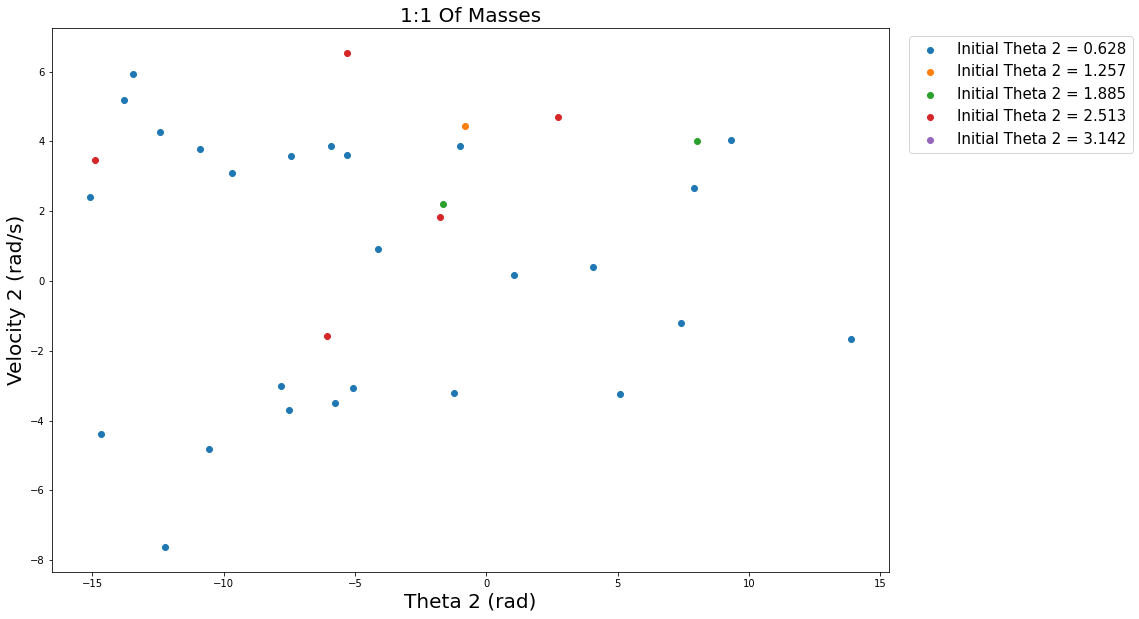

0

In [39]:
t1 = 50

m2 = m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"1:1 Of Masses")
double_p.PoincareFull(5, "1:1 Of Masses")

1
2
3
4
5


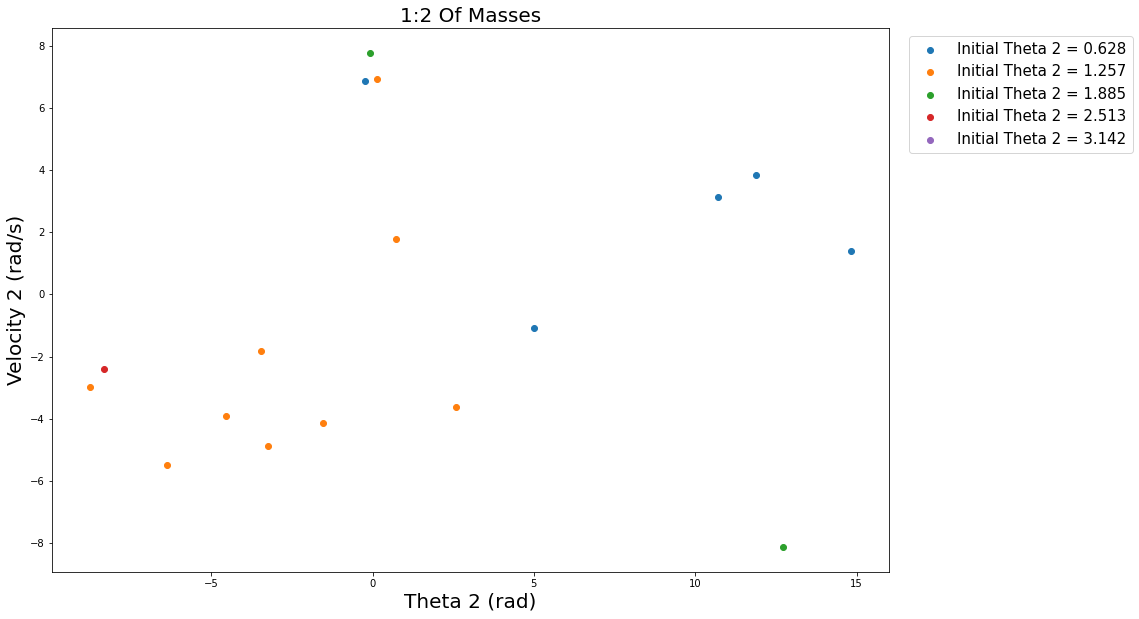

0

In [40]:
m2 = 2*m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"1:2 Of Masses")
double_p.PoincareFull(5, "1:2 Of Masses")

1
2
3
4
5


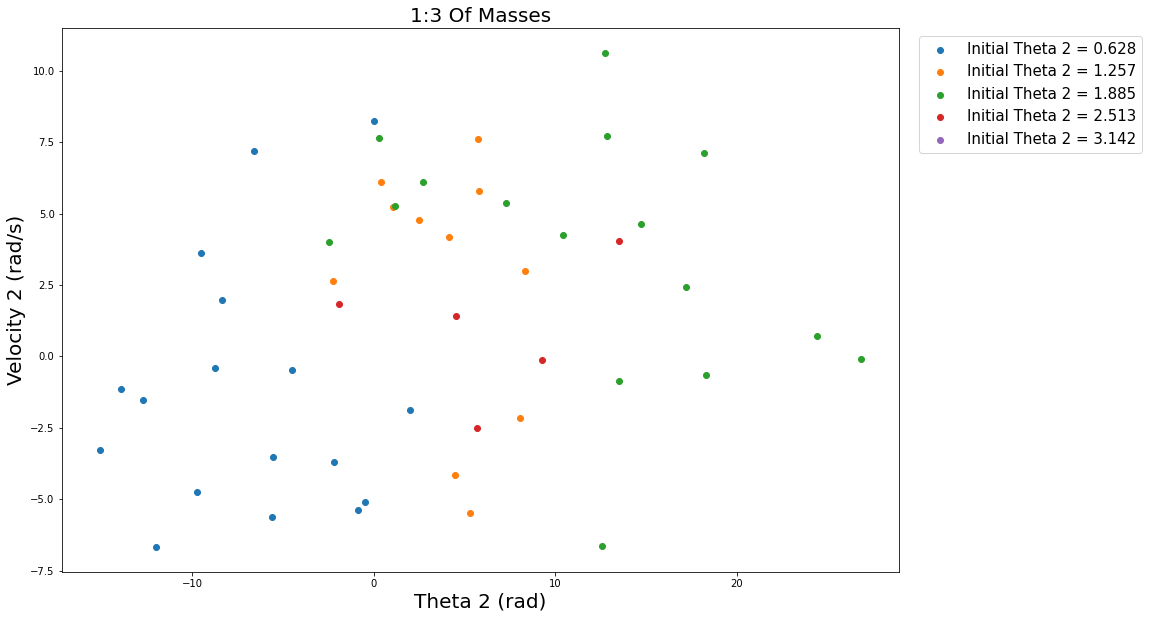

0

In [41]:
m2 = 3*m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"1:3 Of Masses")
double_p.PoincareFull(5, "1:3 Of Masses")

1
2
3
4
5


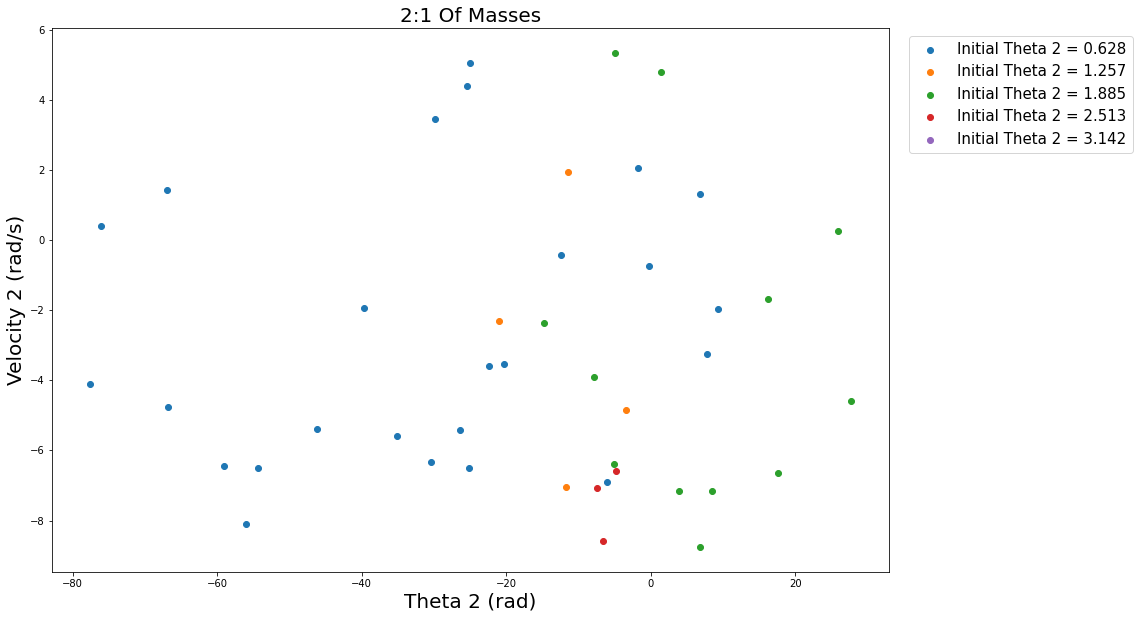

0

In [42]:
m2 = 0.5*m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"2:1 Of Masses")
double_p.PoincareFull(5, "2:1 Of Masses")

1
2
3
4
5


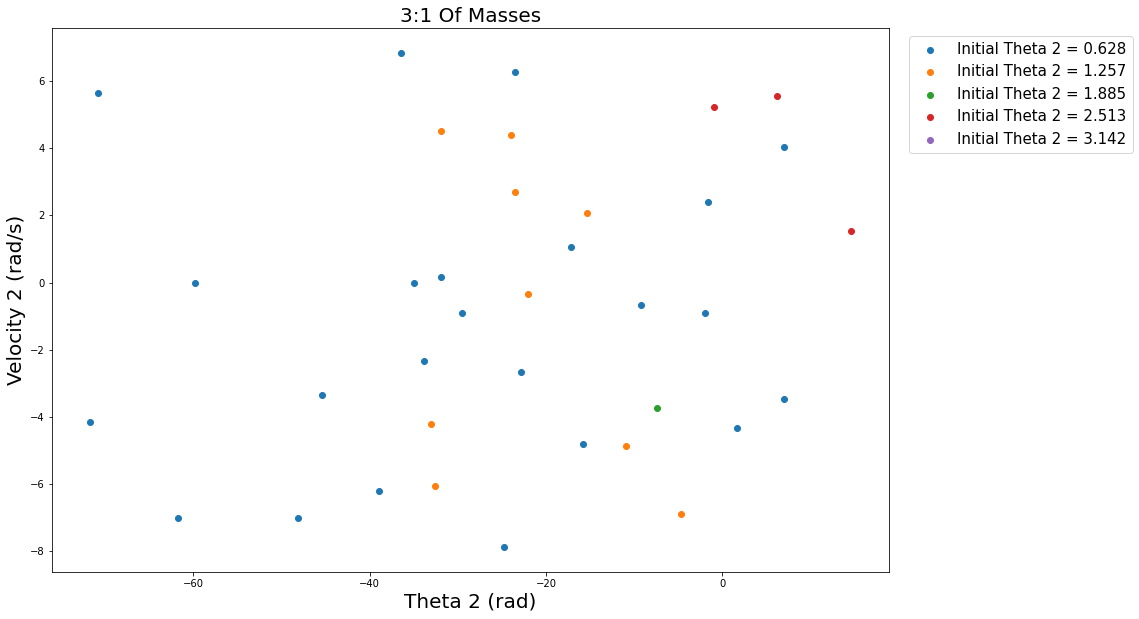

0

In [43]:
m2 = 1/3*m1

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
#double_p.Poincare(Full"3:1 Of Masses")
double_p.PoincareFull(5, "3:1 Of Masses")

# Visualisation

In [47]:
from PIL import Image
import time, os

In [52]:
t1 = 10

theta1_0 = np.pi/3
theta2_0 = np.pi/16

g = 9.8

v1_0 = 0
v2_0 = 0

l1 = 1
l2 = l1

m1 = 1
m2 = m1

h = 0.0005

double_p = Double_Pendulum(t1, g, l1, l2, m1, m2, theta1_0, theta2_0, v1_0, v2_0)
t, theta1, theta2, v1, v2 = double_p.RK4(theta2_0, v2_0, h)

x1 = l1*np.sin(theta1)
y1 = -l1*np.cos(theta1)

x2 = x1 + l2*np.sin(theta2)
y2 = y1 - l2*np.cos(theta2)

frames = []
for i in range(len(x1)):
    if i%50 == 0:
        fig=plt.figure()
        plt.plot((0, x1[i]), (0, y1[i]))
        plt.plot((x1[i], x2[i]), (y1[i], y2[i]))
        plt.xlim(-2.2, 2.2)
        plt.ylim(-2.2, 2.2)
    
        canvas = plt.get_current_fig_manager().canvas
        canvas.draw()
        im = Image.frombytes('RGB', canvas.get_width_height(), canvas.tostring_rgb())
        frames.append(im)
            
    plt.close(fig)
    #plt.show(fig)

frames[0].save("Double Pendulum.gif", format='GIF', append_images=frames[1:], save_all=True, duration=100, loop=0)

<Figure size 720x720 with 0 Axes>

### References

For Runga-Kutte: https://www.physics.umd.edu/hep/drew/pendulum2.html

In [46]:
end = time.time()
print("This took", end-start, "seconds to run")

This took 3477.3169298171997 seconds to run


In [ ]:
from sympy import symbols, log

# Given values
R1 = 10e3  # Ohms
C1 = 10**-6  # Farads
R2 = 100e3  # Ohms
C2 = 10**-9  # Farads

# Calculate the cutoff frequencies (in rad/s)
omega_HP = 1 / (R1 * C1)  # High-pass cutoff frequency
omega_LP = 1 / (R2 * C2)  # Low-pass cutoff frequency

# Convert to Hz (f = omega / (2 * pi))
f_HP = omega_HP / (2 * 3.14159)  # High-pass cutoff frequency in Hz
f_LP = omega_LP / (2 * 3.14159)  # Low-pass cutoff frequency in Hz

omega_HP, omega_LP, f_HP, f_LP
